# Supervised ML project using decision trees

## MODEL TO PREDICT WHETHER CUSTOMER WILL CHURN OR NOT

### Churn - Customer will stop using company product

In [ ]:
# RUN THESE CELLS TO START THE PROJECT!
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('../DATA/Telco-Customer-Churn.csv')


In [ ]:
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


In [ ]:
df.describe().transpose()


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7032.0,0.162400,0.368844,0.00,0.0000,0.000,0.0000,1.00
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00
MonthlyCharges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80


# Exploratory Data Analysis

In [ ]:
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

<Axes: xlabel='Churn', ylabel='count'>

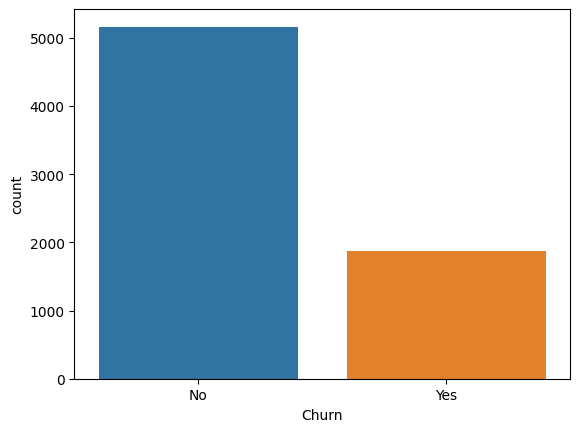

In [ ]:
sns.countplot(x = df['Churn'] , hue = df['Churn'])


<Axes: xlabel='Churn', ylabel='TotalCharges'>

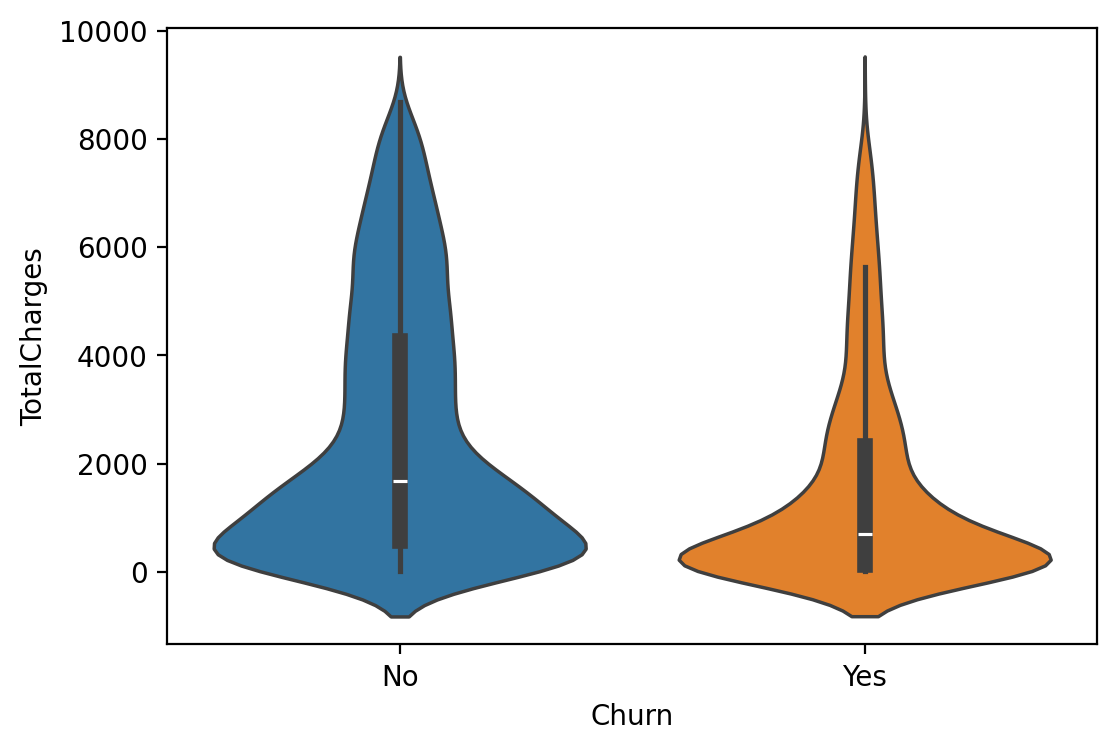

In [ ]:
plt.figure(figsize = (6,4) , dpi = 200)
sns.violinplot(x = 'Churn' , y = 'TotalCharges' , data = df , hue = 'Churn')


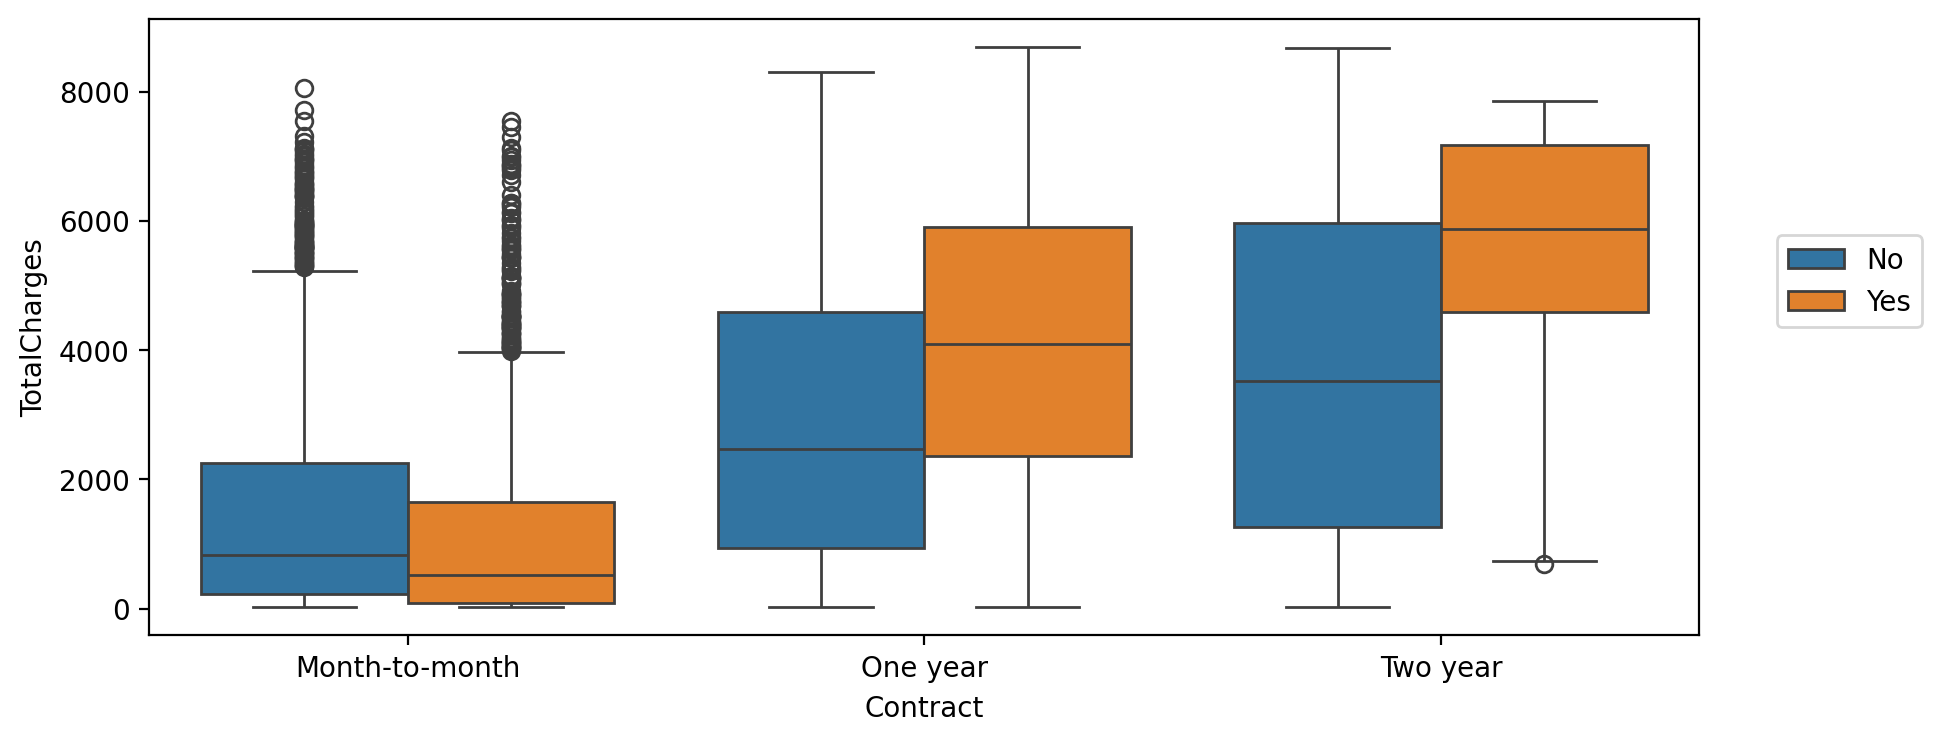

In [ ]:
plt.figure(figsize = (10,4) , dpi = 200)
sns.boxplot(x = 'Contract' , y = 'TotalCharges' , hue = 'Churn' , data = df)
plt.legend(loc = [1.05,0.5]);


In [ ]:
df.corr(numeric_only = True)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.015683,0.219874,0.102411
tenure,0.015683,1.000000,0.246862,0.825880
MonthlyCharges,0.219874,0.246862,1.000000,0.651065
TotalCharges,0.102411,0.825880,0.651065,1.000000


In [ ]:
df_ = pd.get_dummies(df.drop('customerID',axis = 1))


In [ ]:
df


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7028,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7029,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7030,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [ ]:
df['Churn'].value_counts()


Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [ ]:
df_


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_No,Churn_Yes
0,0,1,29.85,29.85,True,False,False,True,True,False,...,False,False,False,True,False,False,True,False,True,False
1,0,34,56.95,1889.50,False,True,True,False,True,False,...,True,False,True,False,False,False,False,True,True,False
2,0,2,53.85,108.15,False,True,True,False,True,False,...,False,False,False,True,False,False,False,True,False,True
3,0,45,42.30,1840.75,False,True,True,False,True,False,...,True,False,True,False,True,False,False,False,True,False
4,0,2,70.70,151.65,True,False,True,False,True,False,...,False,False,False,True,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0,24,84.80,1990.50,False,True,False,True,False,True,...,True,False,False,True,False,False,False,True,True,False
7028,0,72,103.20,7362.90,True,False,False,True,False,True,...,True,False,False,True,False,True,False,False,True,False
7029,0,11,29.60,346.45,True,False,False,True,False,True,...,False,False,False,True,False,False,True,False,True,False
7030,1,4,74.40,306.60,False,True,False,True,True,False,...,False,False,False,True,False,False,False,True,False,True


In [ ]:
df_.columns


Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Female', 'gender_Male', 'Partner_No', 'Partner_Yes',
       'Dependents_No', 'Dependents_Yes', 'PhoneService_No',
       'PhoneService_Yes', 'MultipleLines_No',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', '

In [ ]:
df.drop('customerID',axis = 1).columns


Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
df_.corr().sort_values('Churn_Yes')['Churn_Yes'][1:-1]


tenure                                    -0.354049
Contract_Two year                         -0.301552
OnlineBackup_No internet service          -0.227578
DeviceProtection_No internet service      -0.227578
InternetService_No                        -0.227578
StreamingTV_No internet service           -0.227578
TechSupport_No internet service           -0.227578
OnlineSecurity_No internet service        -0.227578
StreamingMovies_No internet service       -0.227578
TotalCharges                              -0.199484
PaperlessBilling_No                       -0.191454
Contract_One year                         -0.178225
OnlineSecurity_Yes                        -0.171270
TechSupport_Yes                           -0.164716
Dependents_Yes                            -0.163128
Partner_Yes                               -0.149982
PaymentMethod_Credit card (automatic)     -0.134687
InternetService_DSL                       -0.124141
PaymentMethod_Bank transfer (automatic)   -0.118136
PaymentMetho

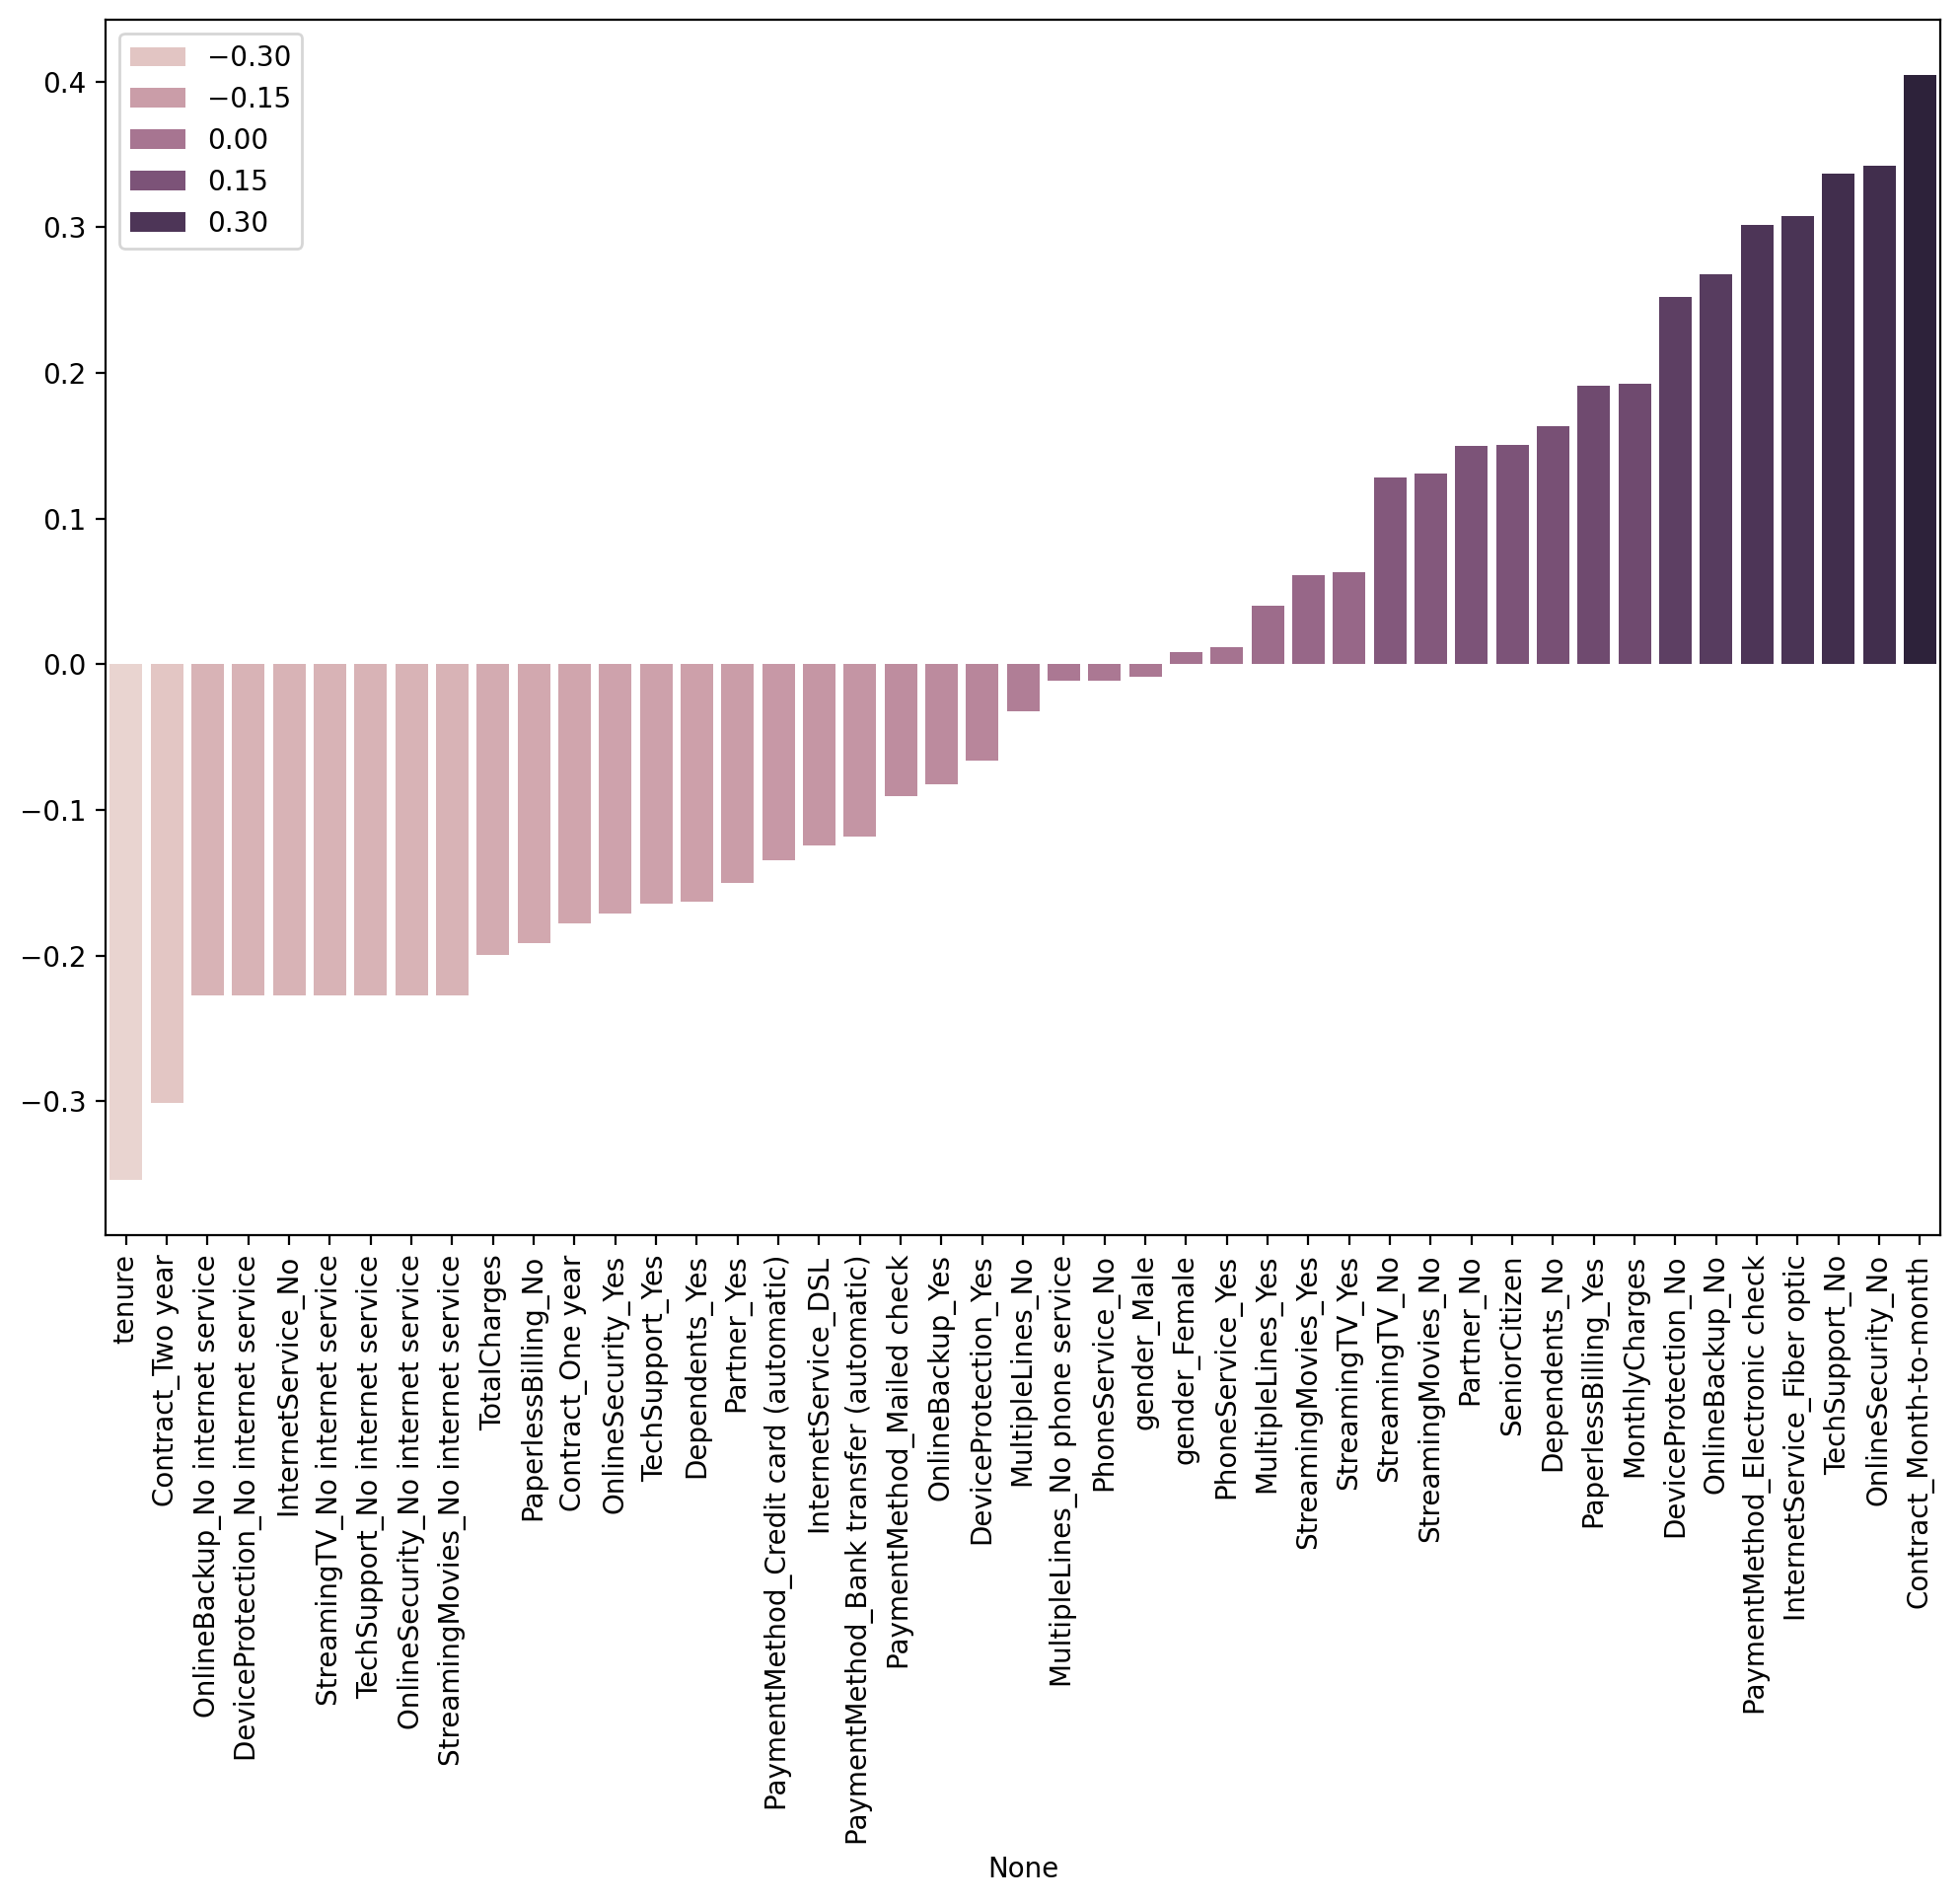

In [ ]:
plt.figure(figsize = (12,8) , dpi = 200)
sns.barplot(x = df_.corr().sort_values('Churn_Yes')['Churn_Yes'][1:-1].index , y = df_.corr().sort_values('Churn_Yes')['Churn_Yes'][1:-1].values , hue = df_.corr().sort_values('Churn_Yes')['Churn_Yes'][1:-1].values)
plt.xticks(rotation = 90);


#  Churn Analysis

In [ ]:
df['Contract'].unique()


array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [ ]:
df['tenure']


0        1
1       34
2        2
3       45
4        2
        ..
7027    24
7028    72
7029    11
7030     4
7031    66
Name: tenure, Length: 7032, dtype: int64

<Figure size 2400x800 with 0 Axes>

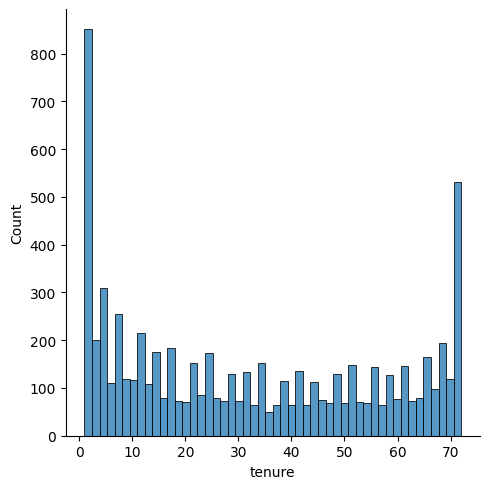

In [ ]:
plt.figure(figsize = (12,4) , dpi = 200);
sns.displot(x = 'tenure' , data = df , bins = 50);


<Figure size 2400x800 with 0 Axes>

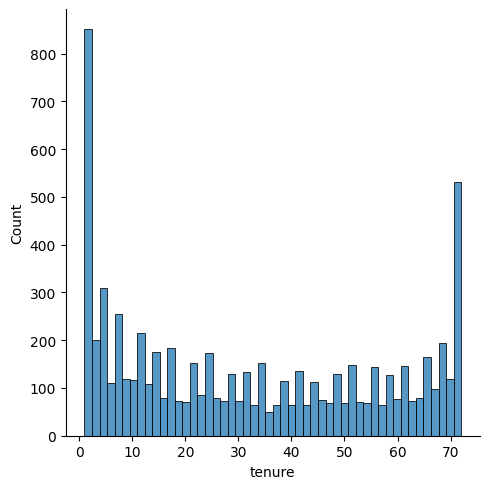

In [ ]:
plt.figure(figsize = (12,4) , dpi = 200);
sns.displot(x = 'tenure' , data = df , bins = 50);


<Figure size 2000x1600 with 0 Axes>

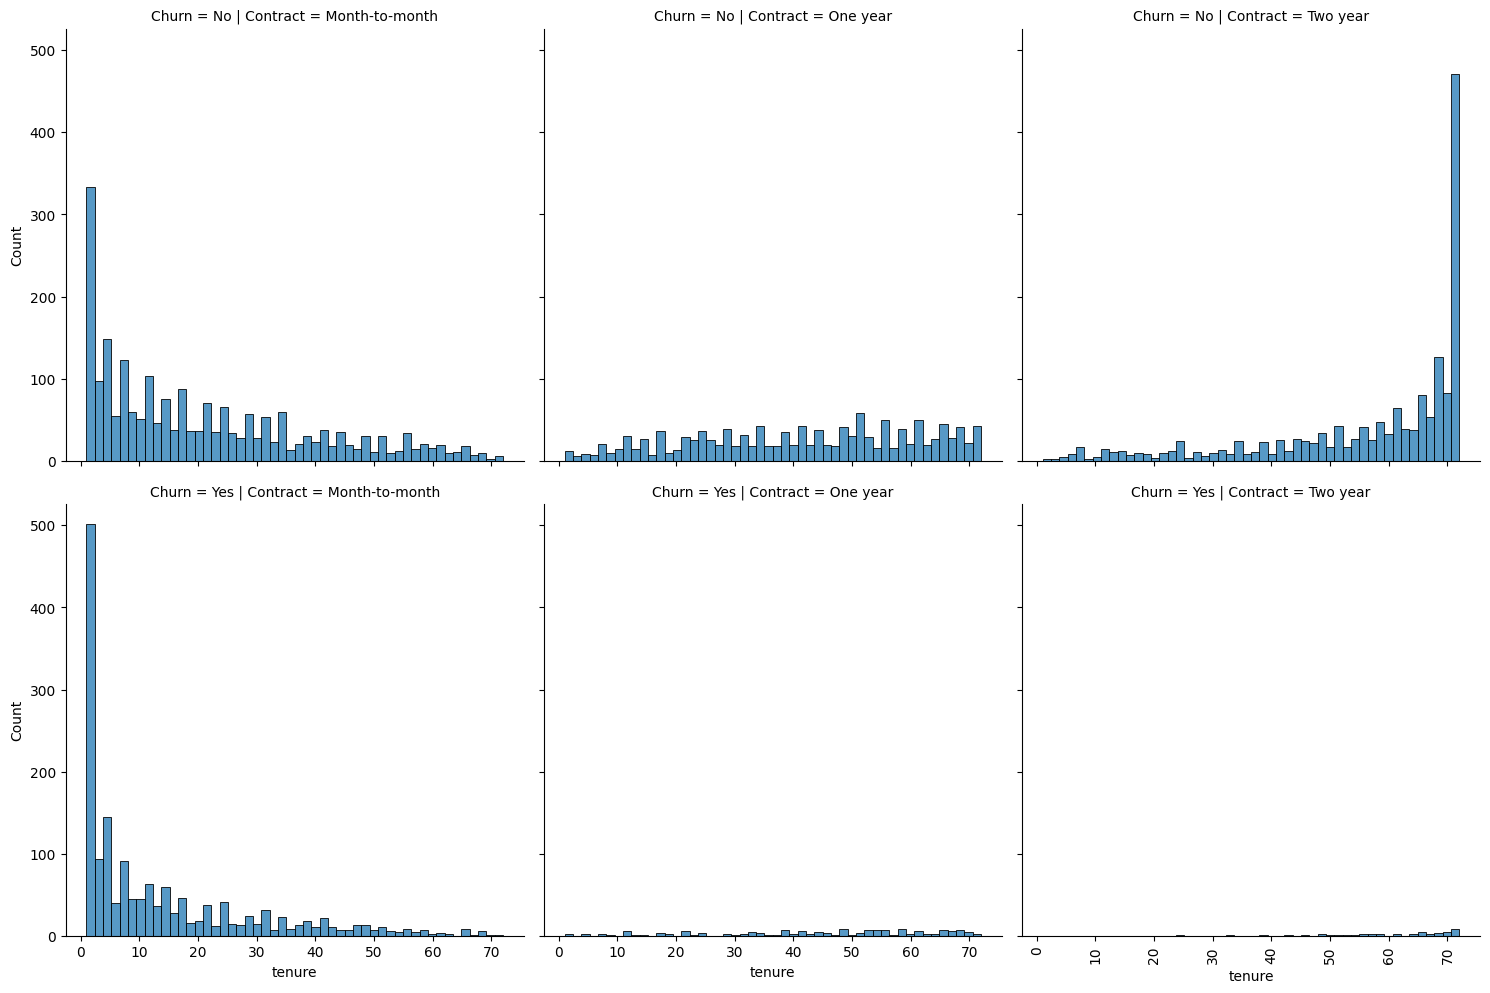

In [ ]:
plt.figure(figsize = (10,8) , dpi = 200)
sns.displot(row = 'Churn' , col =  'Contract' ,x = 'tenure' , data = df , kind = 'hist' , bins = 50 );
plt.xticks(rotation = 90);


In [ ]:
help(sns.catplot)


Help on function catplot in module seaborn.categorical:

catplot(data=None, *, x=None, y=None, hue=None, row=None, col=None, kind='strip', estimator='mean', errorbar=('ci', 95), n_boot=1000, seed=None, units=None, weights=None, order=None, hue_order=None, row_order=None, col_order=None, col_wrap=None, height=5, aspect=1, log_scale=None, native_scale=False, formatter=None, orient=None, color=None, palette=None, hue_norm=None, legend='auto', legend_out=True, sharex=True, sharey=True, margin_titles=False, facet_kws=None, ci=<deprecated>, **kwargs)
    Figure-level interface for drawing categorical plots onto a FacetGrid.
    
    This function provides access to several axes-level functions that
    show the relationship between a numerical and one or more categorical
    variables using one of several visual representations. The `kind`
    parameter selects the underlying axes-level function to use.
    
    Categorical scatterplots:
    
    - :func:`stripplot` (with `kind="strip"`; the

In [ ]:
df


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7028,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7029,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7030,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


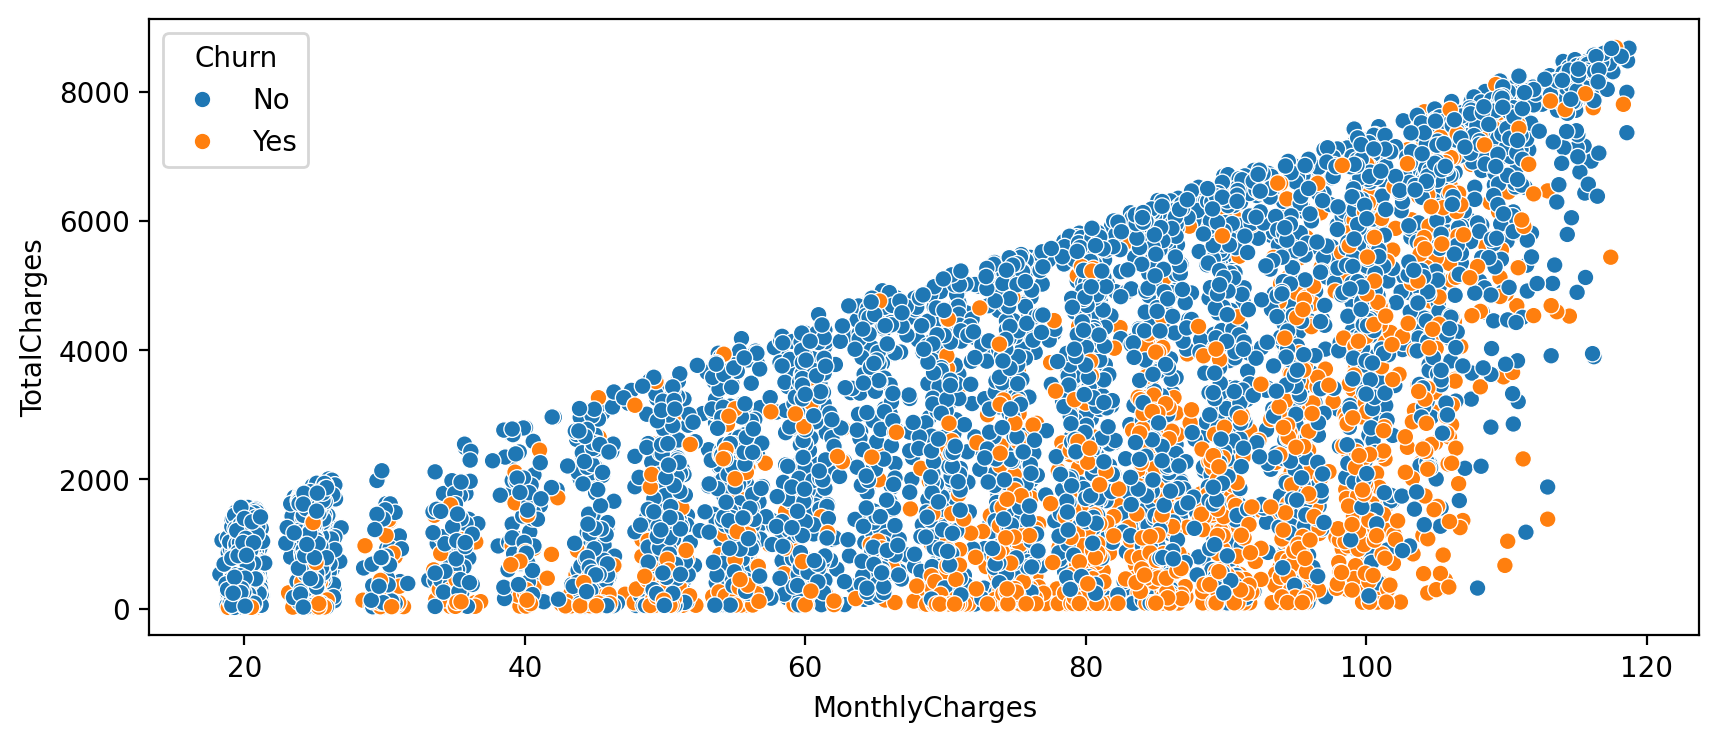

In [ ]:
plt.figure(figsize = (10,4) , dpi = 200)
sns.scatterplot(x = 'MonthlyCharges' , y = 'TotalCharges' , data = df , hue = 'Churn');


In [ ]:
df.columns


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
def yn_(o):
    if o == 'No':
        return 0
    else:
        return 1


In [ ]:
df['Churn_'] = np.vectorize(yn_)(df['Churn'])


In [ ]:
df


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,0
7028,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,0
7029,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0
7030,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,1


In [ ]:
df__ = df.groupby('tenure')['Churn_'].mean()


In [ ]:
df__*100


tenure
1     61.990212
2     51.680672
3     47.000000
4     47.159091
5     48.120301
        ...    
68     9.000000
69     8.421053
70     9.243697
71     3.529412
72     1.657459
Name: Churn_, Length: 72, dtype: float64

Text(0, 0.5, 'Churn Percentage')

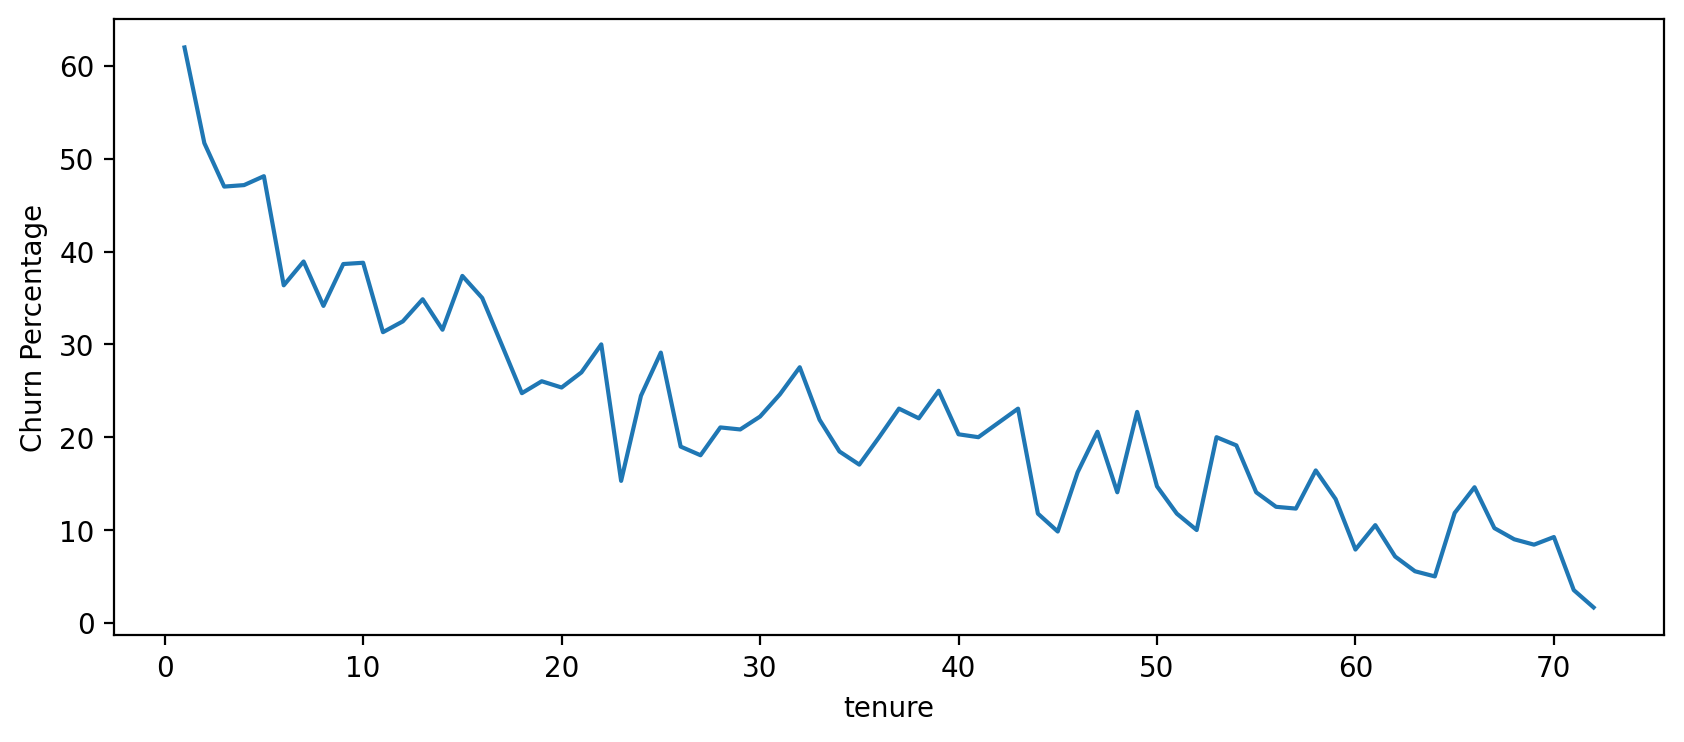

In [ ]:
plt.figure(figsize = (10,4) , dpi = 200)
plt.plot(df__.index,df__.values*100)
plt.xlabel('tenure')
plt.ylabel('Churn Percentage')


### Broader Cohort Groups
   * '0-12 Months'
   * '12-24 Months'
   * '24-48 Months'
   * 'Over 48 Months'    

In [ ]:
def ten_(x):
    if x<=12:
        return "0-12 Months"
    elif x<=24:
        return "12-24 Months"
    elif x<=48:
        return "24-48 Months"
    else:
        return "Over 48 Months"


In [ ]:
df["Tenure Cohort"] = np.vectorize(ten_)(df['tenure'])


In [ ]:
df[['Tenure Cohort' , 'tenure']][:14]


,Tenure Cohort,tenure
0,0-12 Months,1
1,24-48 Months,34
2,0-12 Months,2
3,24-48 Months,45
4,0-12 Months,2
5,0-12 Months,8
6,12-24 Months,22
7,0-12 Months,10
8,24-48 Months,28
9,Over 48 Months,62


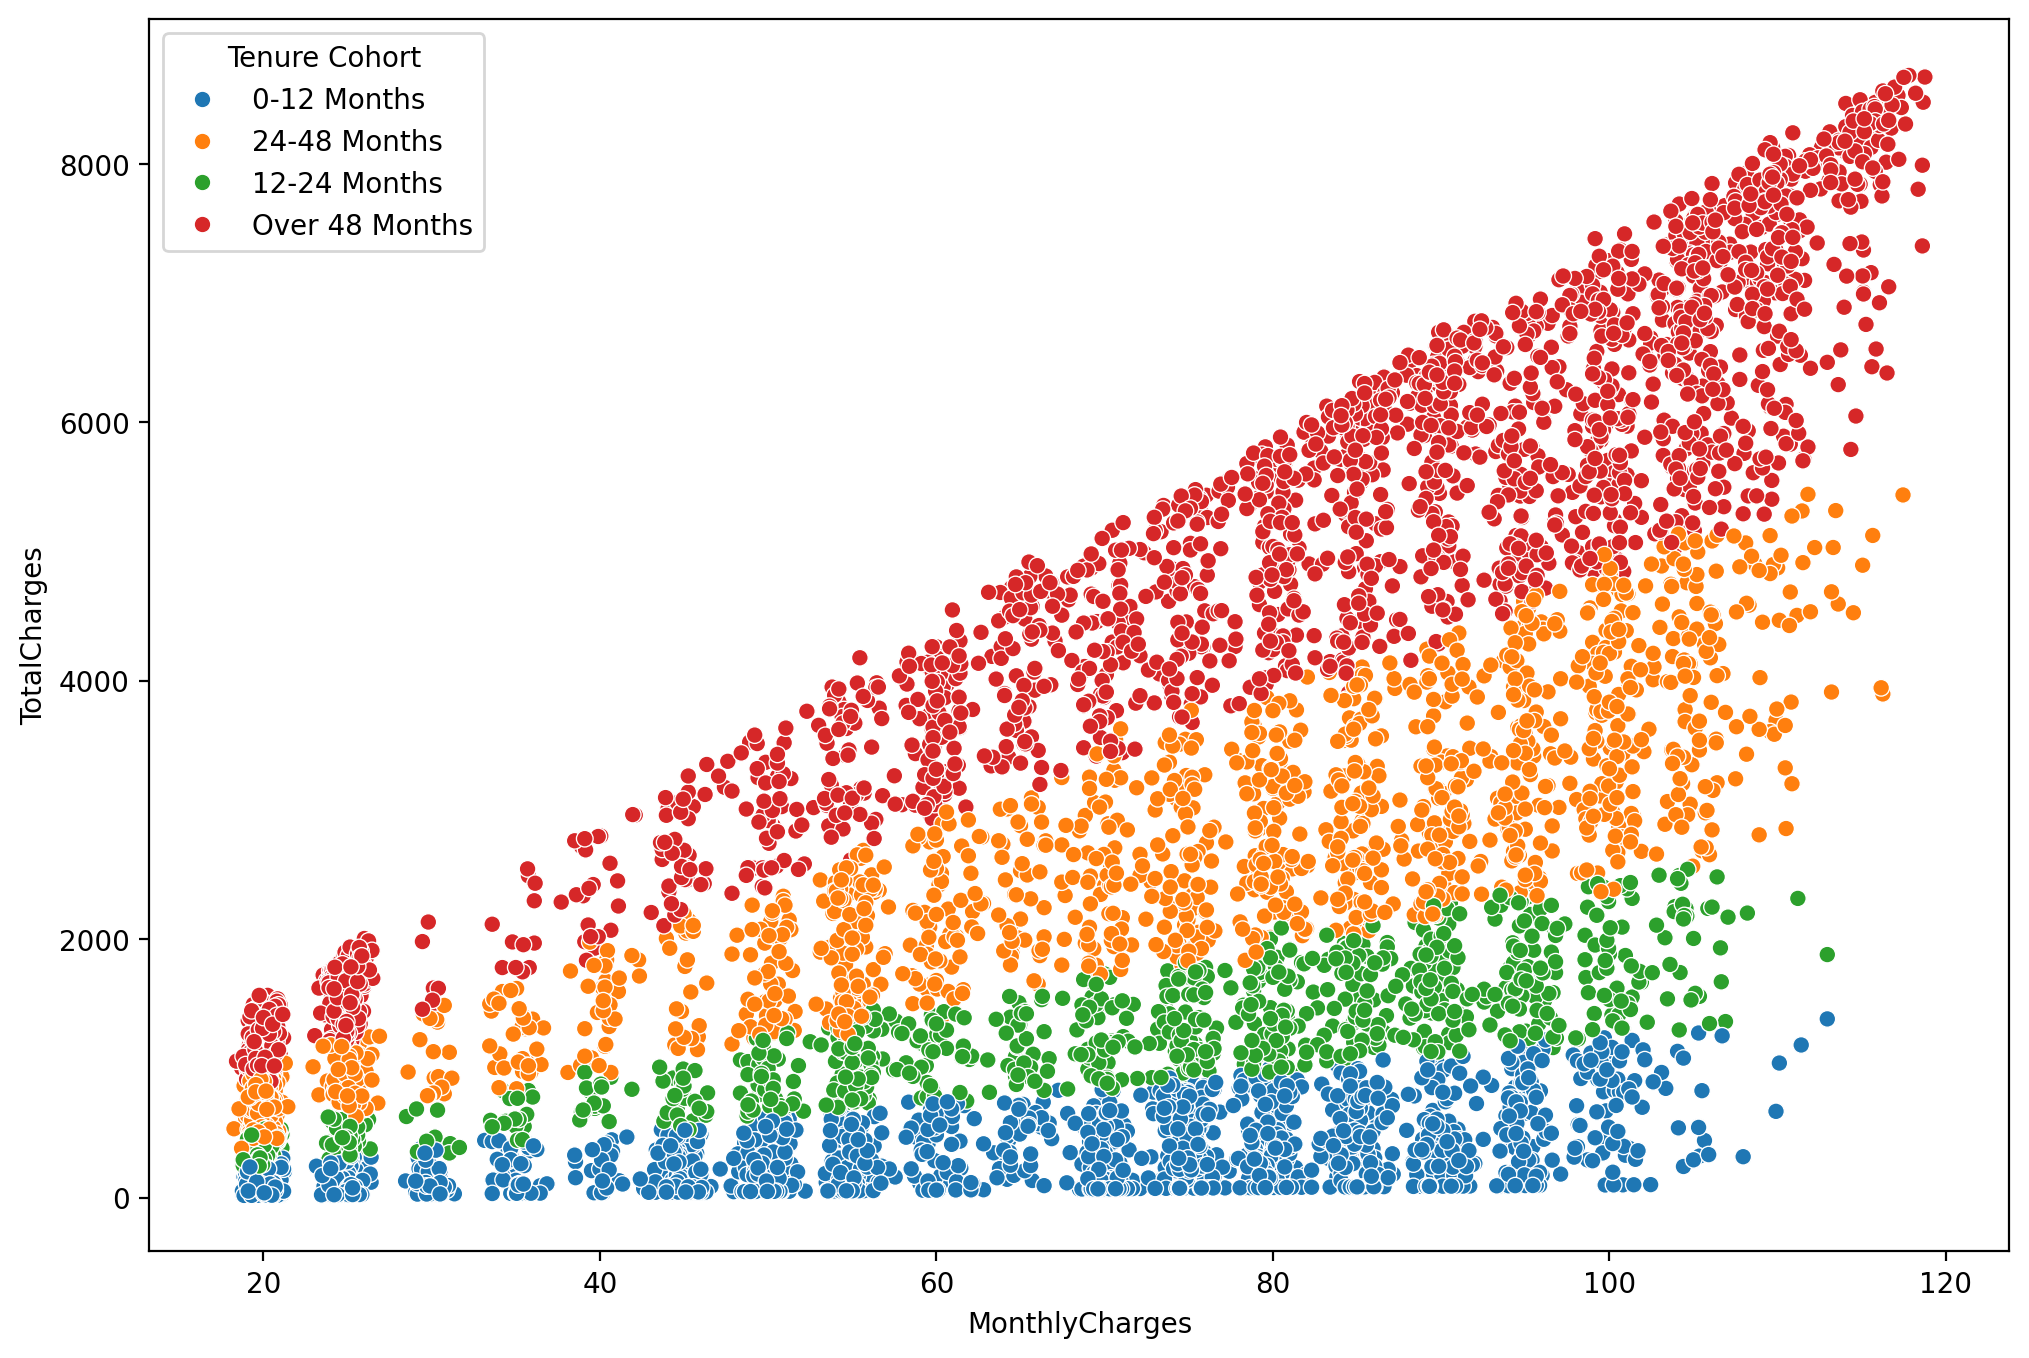

In [ ]:
plt.figure(figsize = (12,8) , dpi = 200)
sns.scatterplot(x = 'MonthlyCharges' , y = 'TotalCharges' , data = df , hue = 'Tenure Cohort');


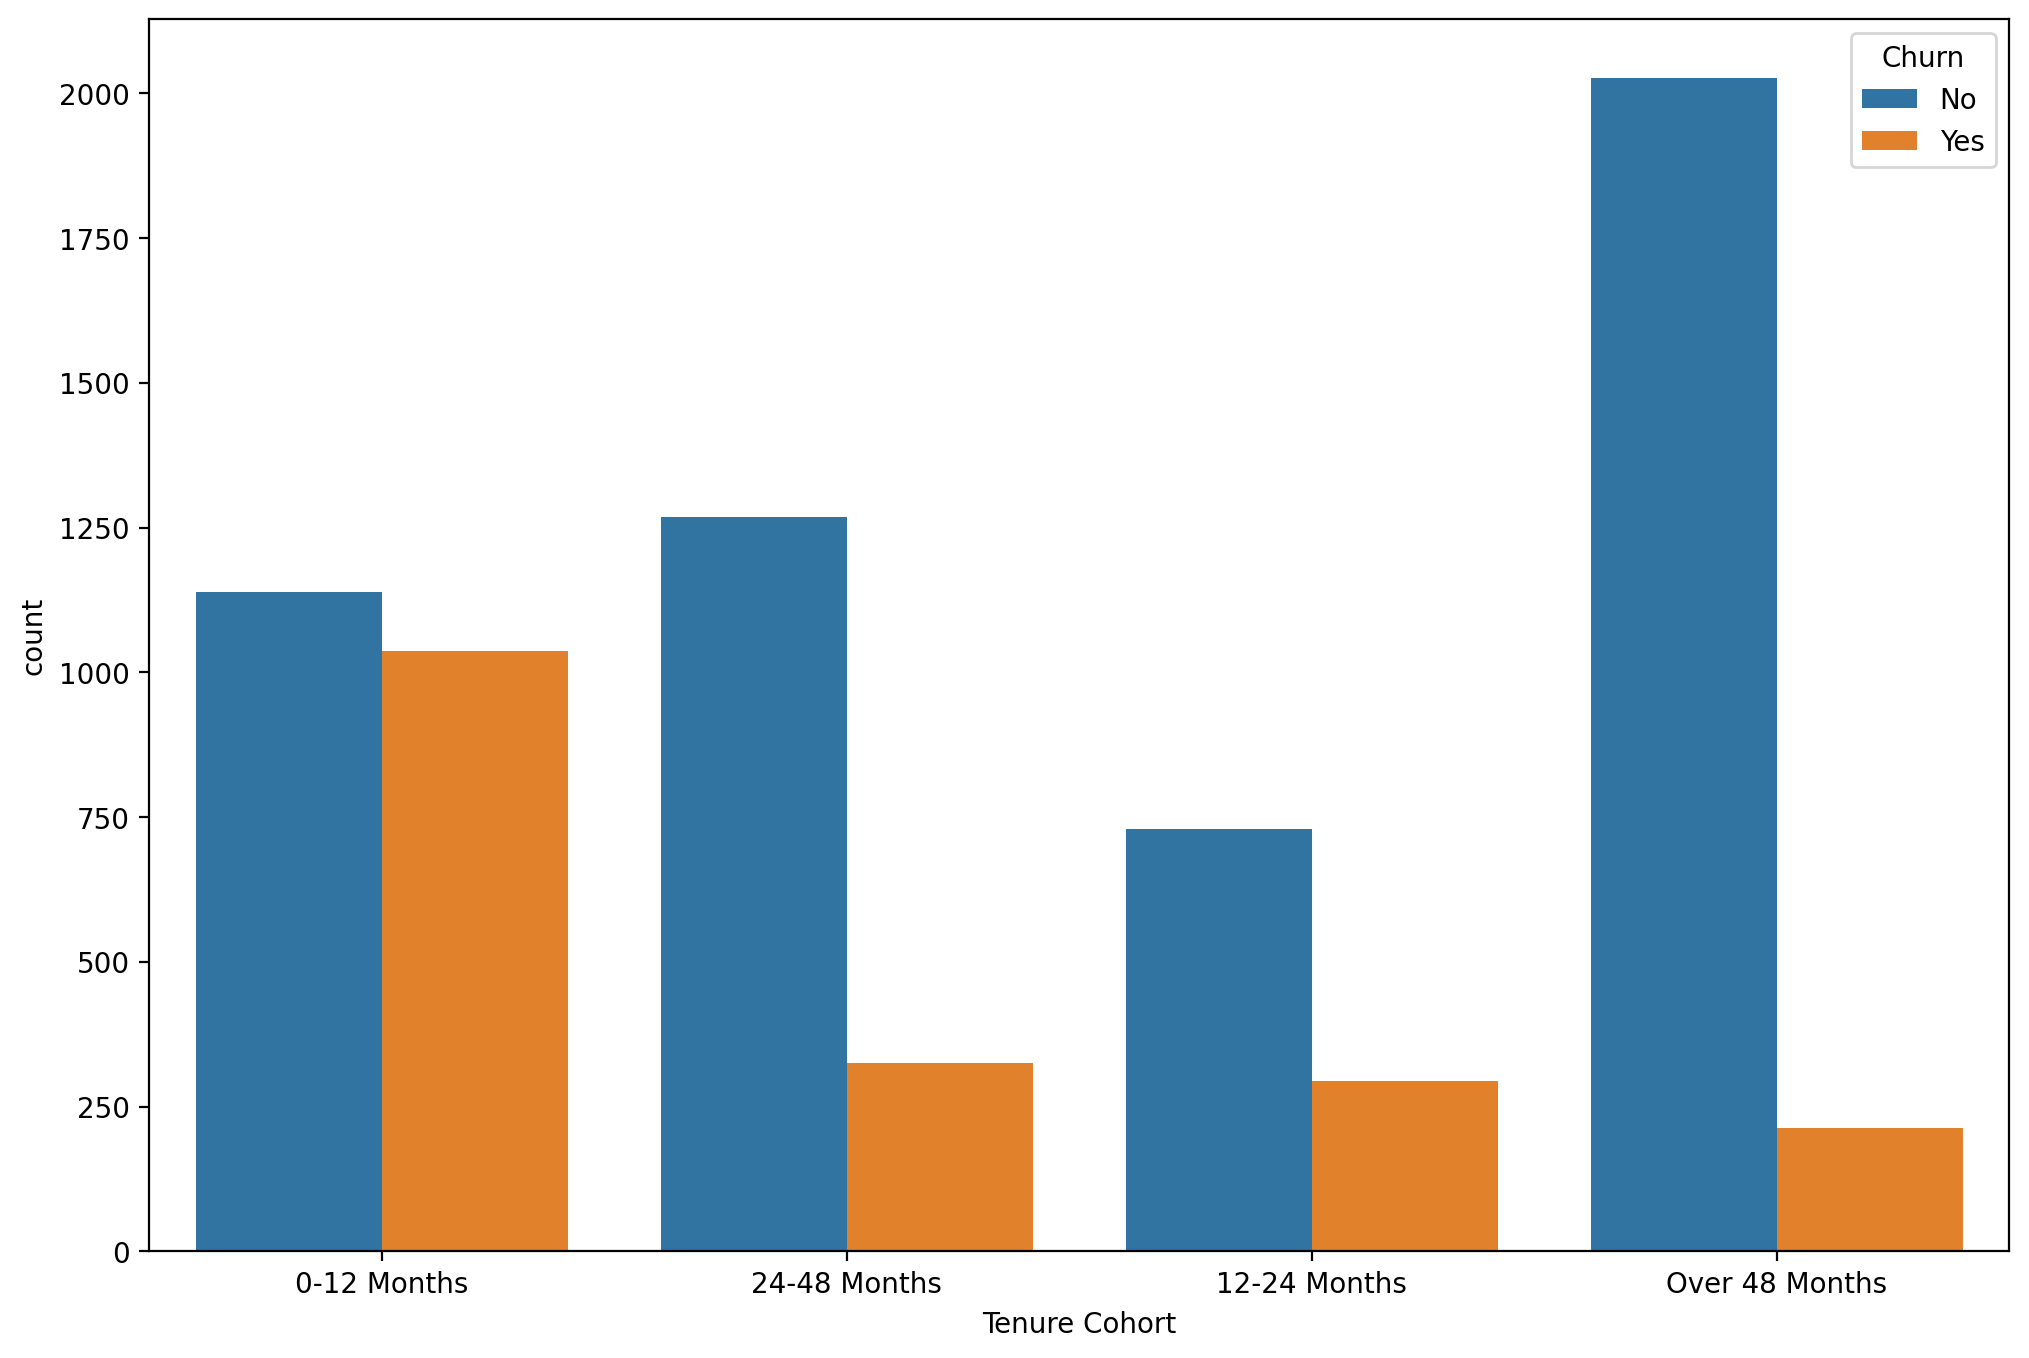

In [ ]:
plt.figure(figsize = (12 , 8) , dpi = 200)
sns.countplot(x = 'Tenure Cohort' , data = df , hue = 'Churn' );


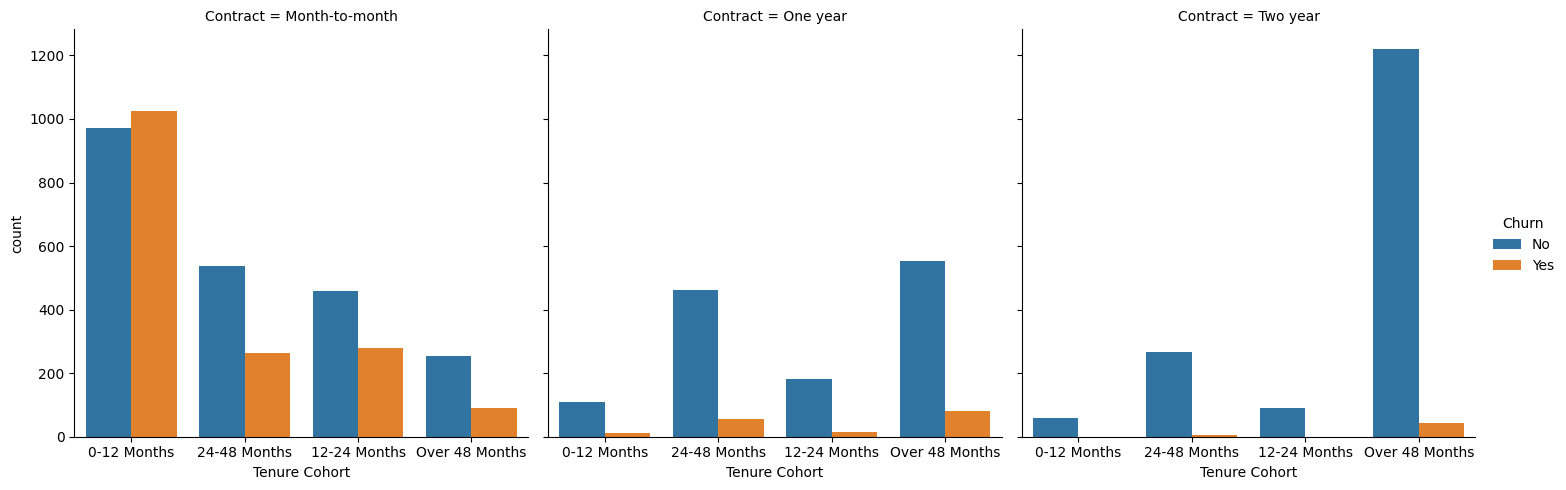

In [ ]:
sns.catplot(x = 'Tenure Cohort' , col = 'Contract' , hue = 'Churn' , data = df , kind = 'count');


-----

# Predictive Modeling

## Single Decision Tree

In [ ]:
dF = pd.get_dummies(df.drop(['customerID','Churn'],axis = 1) , drop_first = True)


In [ ]:
len(dF.columns)


34

In [ ]:
X = dF.drop('Churn_' , axis = 1)
Y = dF['Churn_']


In [ ]:
from sklearn.model_selection import train_test_split


In [ ]:
X_train, X_test , Y_train , Y_test = train_test_split(X , Y ,test_size = 0.1, random_state = 101)


In [ ]:
from sklearn.model_selection import GridSearchCV


In [ ]:
from sklearn.metrics import confusion_matrix , classification_report


In [ ]:
from sklearn.tree import DecisionTreeClassifier


In [ ]:
help(DecisionTreeClassifier)


Help on class DecisionTreeClassifier in module sklearn.tree._classes:

class DecisionTreeClassifier(sklearn.base.ClassifierMixin, BaseDecisionTree)
 |  DecisionTreeClassifier(*, criterion='gini', splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, class_weight=None, ccp_alpha=0.0, monotonic_cst=None)
 |  
 |  A decision tree classifier.
 |  
 |  Read more in the :ref:`User Guide <tree>`.
 |  
 |  Parameters
 |  ----------
 |  criterion : {"gini", "entropy", "log_loss"}, default="gini"
 |      The function to measure the quality of a split. Supported criteria are
 |      "gini" for the Gini impurity and "log_loss" and "entropy" both for the
 |      Shannon information gain, see :ref:`tree_mathematical_formulation`.
 |  
 |  splitter : {"best", "random"}, default="best"
 |      The strategy used to choose the split at each node. Supported
 |      strat

In [ ]:
tree1 = DecisionTreeClassifier()


In [ ]:
param_grid = {
    'criterion' : ['gini'] ,
    'max_depth' : [2,3,4,5,6],
    'class_weight' : ['balanced' , None] , 
    'max_leaf_nodes' : [3,5,7,8,9],
    'min_samples_split' : [10,12,13,9,5]
}


In [ ]:
tree1 = GridSearchCV(tree1 , param_grid = param_grid , scoring = 'accuracy')


In [ ]:
tree1.fit(X_train , Y_train)


GridSearchCV(estimator=DecisionTreeClassifier(),
             param_grid={'class_weight': ['balanced', None],
                         'criterion': ['gini'], 'max_depth': [2, 3, 4, 5, 6],
                         'max_leaf_nodes': [3, 5, 7, 8, 9],
                         'min_samples_split': [10, 12, 13, 9, 5]},
             scoring='accuracy')

In [ ]:
pred1 = tree1.predict(X_test)


In [ ]:
confusion_matrix(Y_test , pred1)


array([[497,  60],
       [ 75,  72]])

In [ ]:
from sklearn.tree import plot_tree


In [ ]:
len(df)


7032

In [ ]:
DF = dF.drop('Churn_' , axis = 1)


In [ ]:
X.columns


Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Tenure Cohort_12-24 Months', 'Tenure Cohort_24-48 Months',
       'Tenure Cohort_Over 48 Months'],
      dtype='object')

In [ ]:
print(classification_report(pred1 , Y_test))


              precision    recall  f1-score   support

           0       0.89      0.87      0.88       572
           1       0.49      0.55      0.52       132

    accuracy                           0.81       704
   macro avg       0.69      0.71      0.70       704
weighted avg       0.82      0.81      0.81       704



In [ ]:
tree1.best_params_


{'class_weight': None,
 'criterion': 'gini',
 'max_depth': 4,
 'max_leaf_nodes': 7,
 'min_samples_split': 10}

In [66]:
param_grid = {'class_weight': [None],
 'criterion': ['gini'],
 'max_depth': [4],
 'max_leaf_nodes': [7],
 'min_samples_split': [10]}

tree1 = DecisionTreeClassifier()
tree1 = GridSearchCV(tree1 , param_grid = param_grid )
tree1.fit(X_train , Y_train)


GridSearchCV(estimator=DecisionTreeClassifier(),
             param_grid={'class_weight': [None], 'criterion': ['gini'],
                         'max_depth': [4], 'max_leaf_nodes': [7],
                         'min_samples_split': [10]})

In [ ]:
confusion_matrix(Y_test , pred1)


array([[497,  60],
       [ 75,  72]])

In [ ]:
print(classification_report(pred1 , Y_test))


              precision    recall  f1-score   support

           0       0.89      0.87      0.88       572
           1       0.49      0.55      0.52       132

    accuracy                           0.81       704
   macro avg       0.69      0.71      0.70       704
weighted avg       0.82      0.81      0.81       704



In [ ]:
tree1 = tree1.best_estimator_


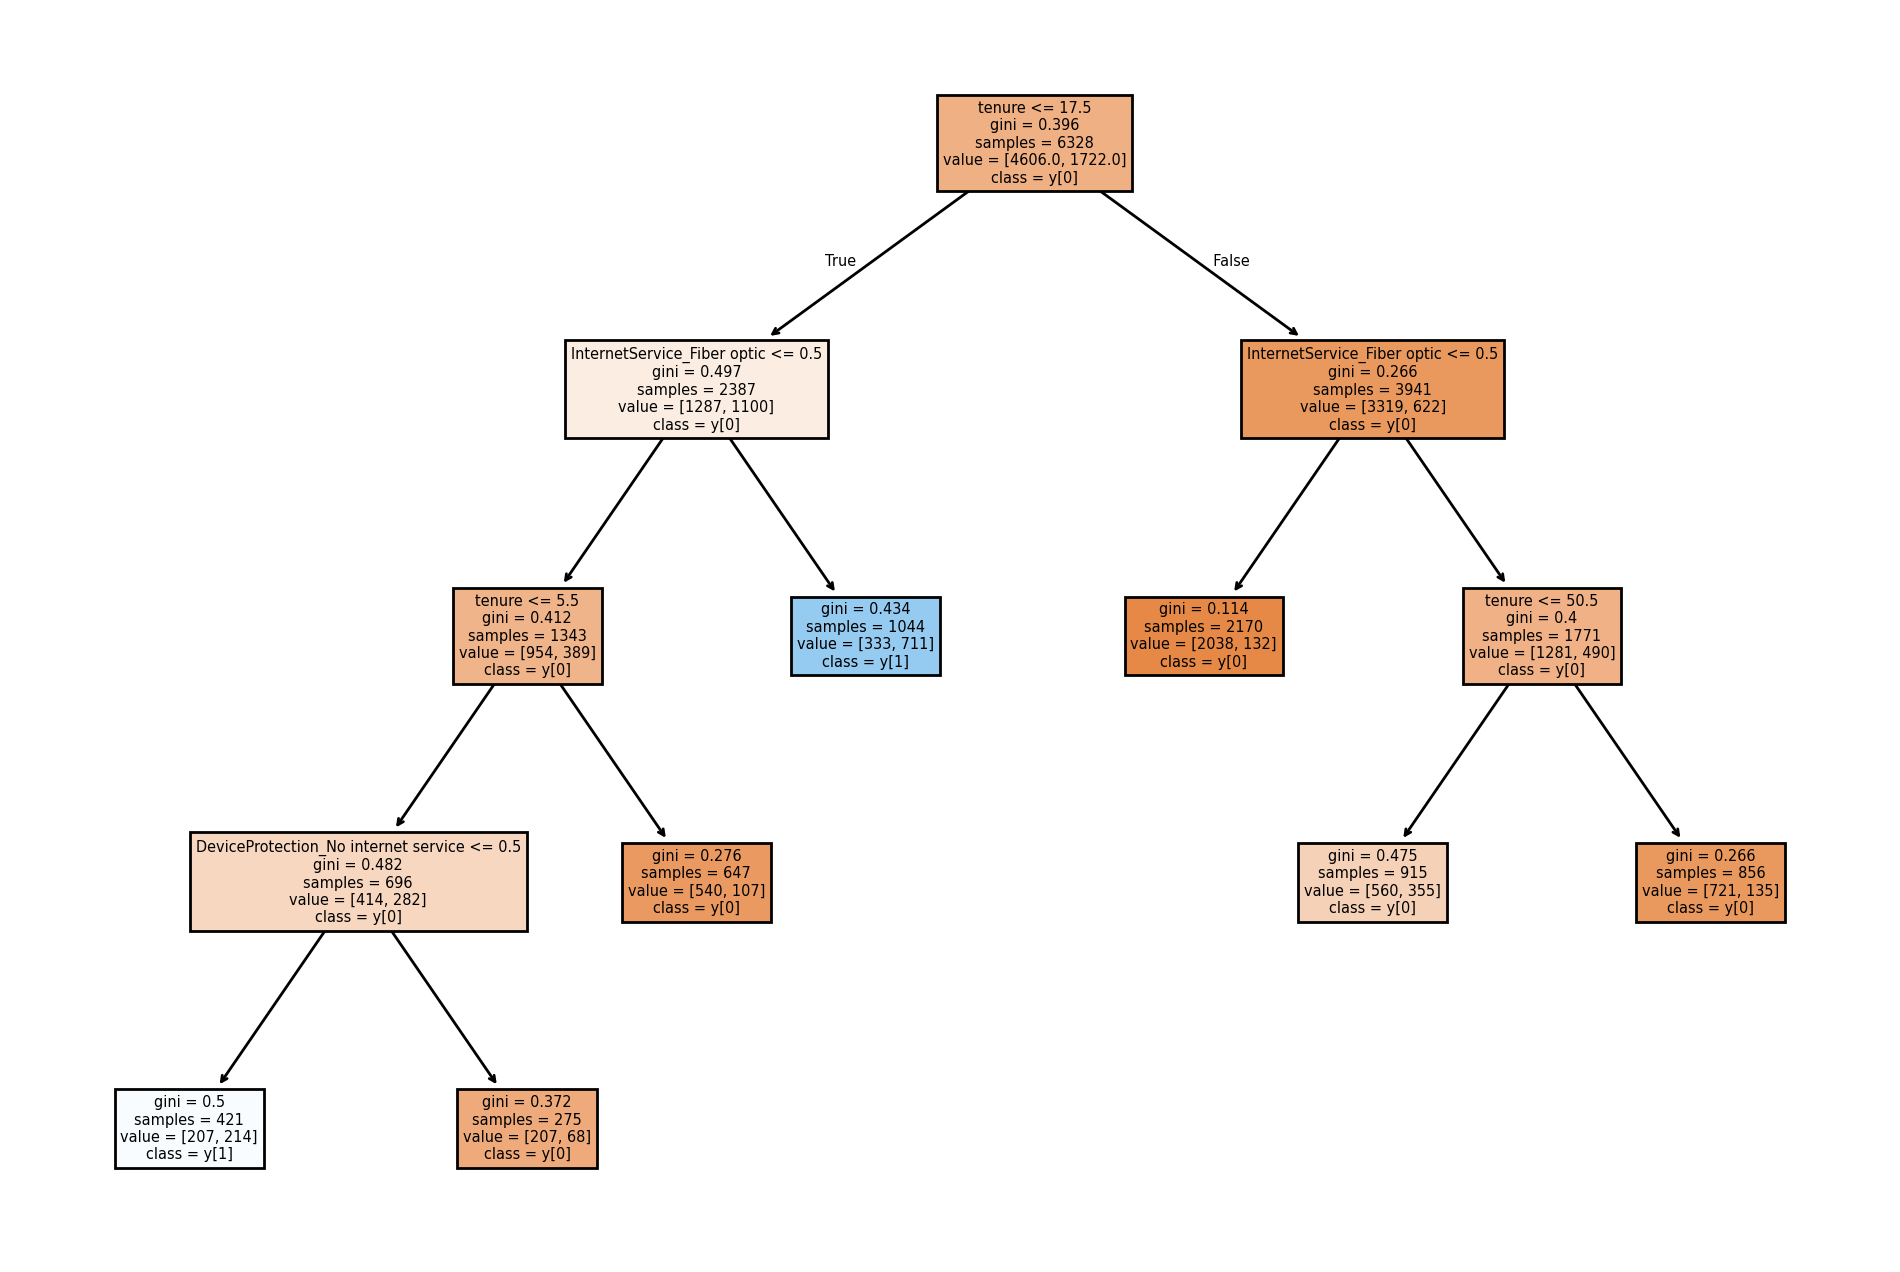

In [ ]:
plt.figure(figsize = (12,8) , dpi = 200)
plot_tree(tree1, filled=True, feature_names=DF.columns, class_names=True);


In [ ]:
Y_train.value_counts()


Churn_
0    4606
1    1722
Name: count, dtype: int64

In [ ]:
557+147


704

In [ ]:
tree1.feature_importances_


array([0.        , 0.54980487, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.41542085, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.03477428, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        ])

## Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier


In [ ]:
help(RandomForestClassifier)


Help on class RandomForestClassifier in module sklearn.ensemble._forest:

class RandomForestClassifier(ForestClassifier)
 |  RandomForestClassifier(n_estimators=100, *, criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0, bootstrap=True, oob_score=False, n_jobs=None, random_state=None, verbose=0, warm_start=False, class_weight=None, ccp_alpha=0.0, max_samples=None, monotonic_cst=None)
 |  
 |  A random forest classifier.
 |  
 |  A random forest is a meta estimator that fits a number of decision tree
 |  classifiers on various sub-samples of the dataset and uses averaging to
 |  improve the predictive accuracy and control over-fitting.
 |  Trees in the forest use the best split strategy, i.e. equivalent to passing
 |  `splitter="best"` to the underlying :class:`~sklearn.tree.DecisionTreeClassifier`.
 |  The sub-sample size is controlled with the `max_samples` paramet

In [ ]:
rfc = RandomForestClassifier()


In [ ]:
rfc.fit(X_train,Y_train)


RandomForestClassifier()

In [ ]:
pred2 = rfc.predict(X_test)


In [ ]:
print(classification_report(Y_test , pred2))


              precision    recall  f1-score   support

           0       0.86      0.89      0.88       557
           1       0.53      0.46      0.49       147

    accuracy                           0.80       704
   macro avg       0.69      0.68      0.68       704
weighted avg       0.79      0.80      0.80       704



In [ ]:
confusion_matrix(Y_test , pred2)


array([[496,  61],
       [ 79,  68]])

## Boosted Trees


In [ ]:
from sklearn.ensemble import AdaBoostClassifier


In [ ]:
abc = AdaBoostClassifier()


In [ ]:
abc.fit(X_train , Y_train)


AdaBoostClassifier()

In [ ]:
pred3 = abc.predict(X_test)


In [ ]:
confusion_matrix(Y_test , pred3)


array([[506,  51],
       [ 72,  75]])

In [ ]:
print(classification_report(Y_test , pred3))


              precision    recall  f1-score   support

           0       0.88      0.91      0.89       557
           1       0.60      0.51      0.55       147

    accuracy                           0.83       704
   macro avg       0.74      0.71      0.72       704
weighted avg       0.82      0.83      0.82       704



In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay


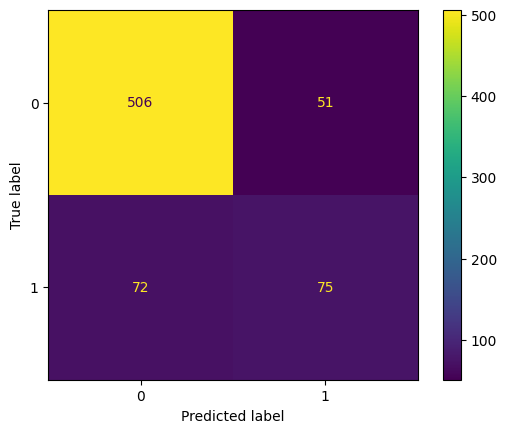

In [ ]:
ConfusionMatrixDisplay.from_estimator(abc , X_test , Y_test)


In [ ]:
dca = DecisionTreeClassifier(max_depth = 6)


In [ ]:
dca.fit(X_train , Y_train)


DecisionTreeClassifier(max_depth=6)

In [ ]:
pred = dca.predict(X_test)


In [ ]:
confusion_matrix(Y_test , pred)


array([[498,  59],
       [ 75,  72]])

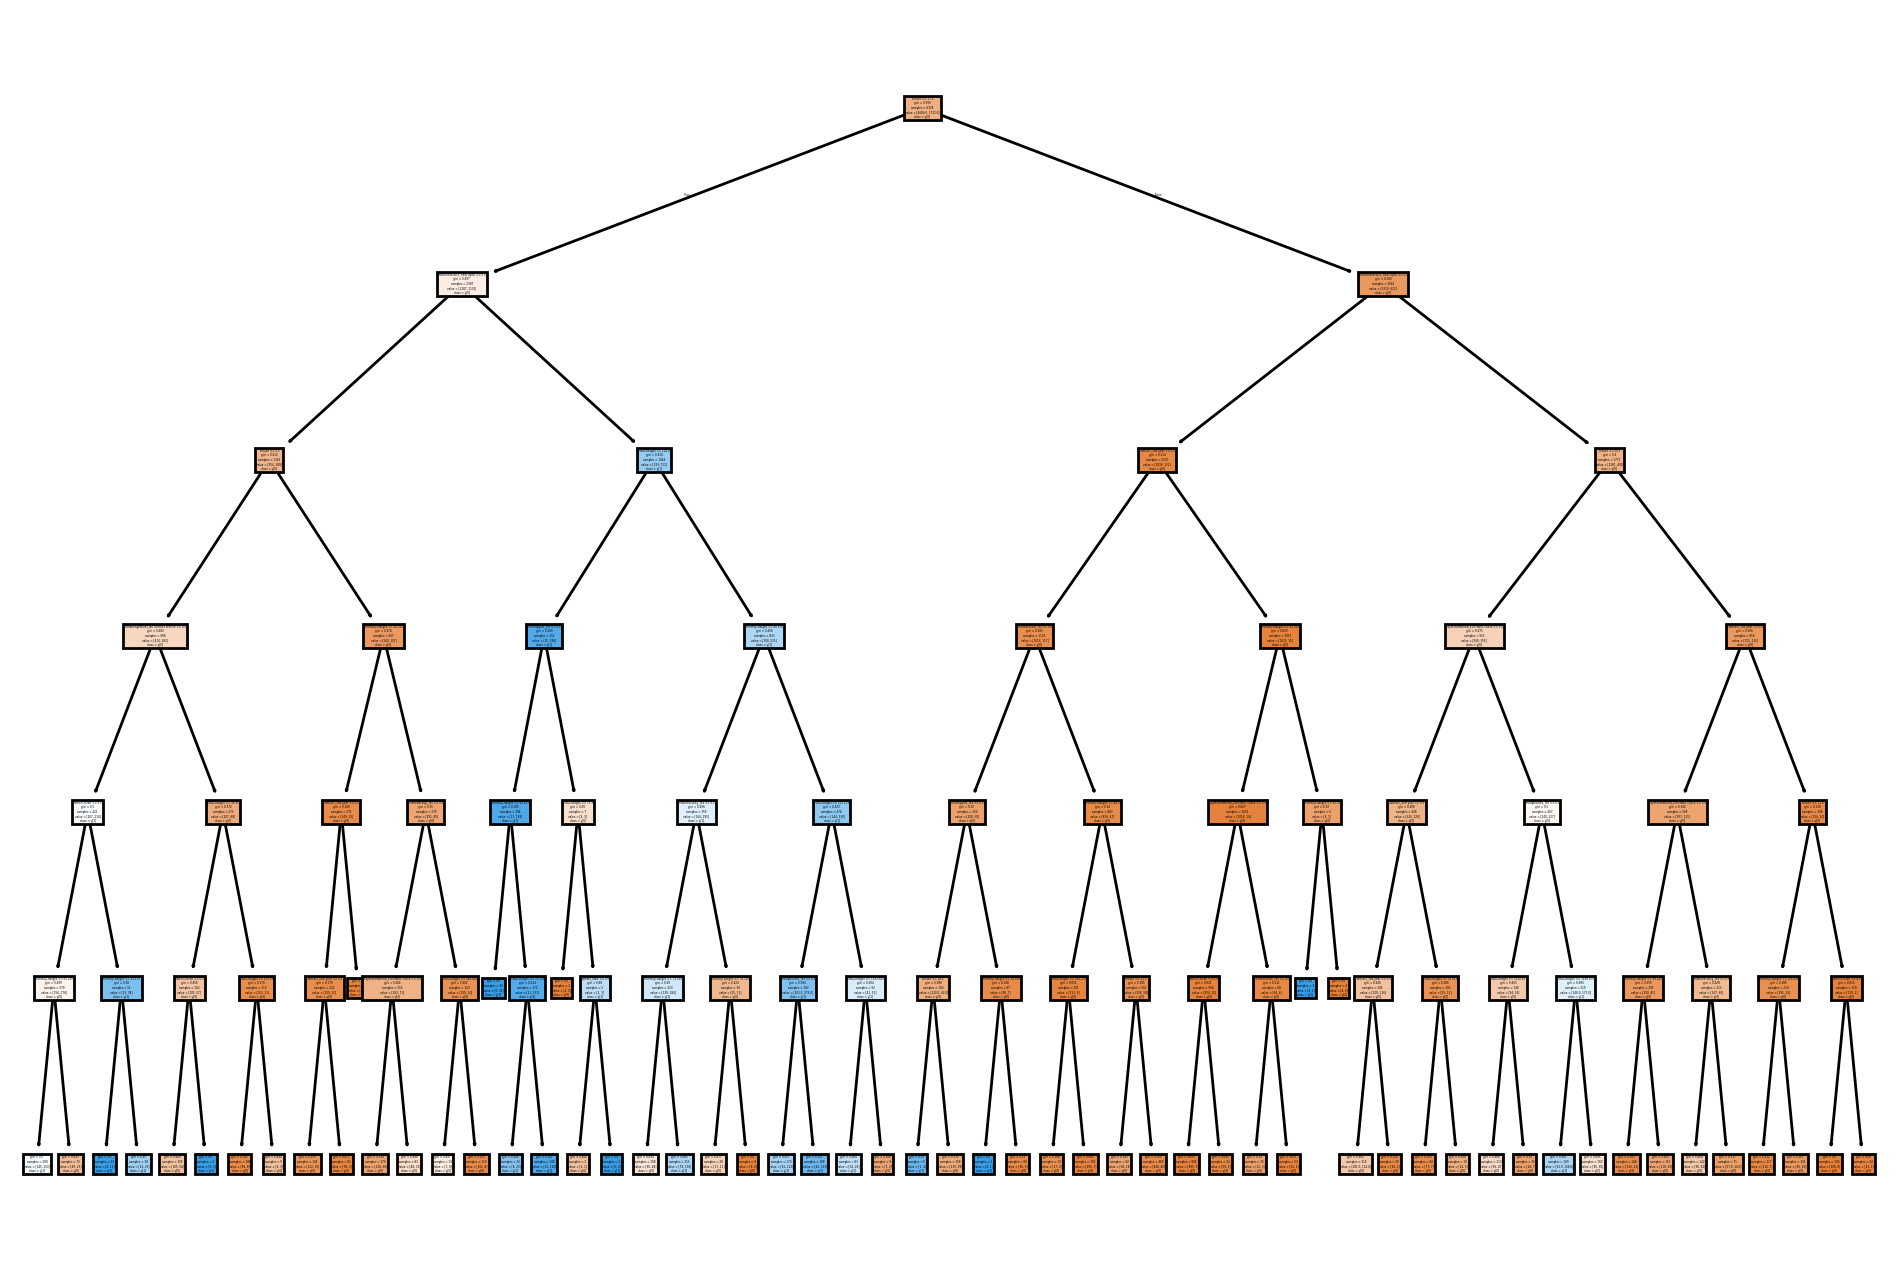

In [ ]:
plt.figure(figsize = (12,8) , dpi = 200)
plot_tree(dca , filled = True , class_names = True , feature_names = X.columns);


In [ ]:
dframe = pd.DataFrame(data = dca.feature_importances_ , index = X.columns , columns = ['Information'])


In [ ]:
dx = dframe.sort_values('Information')
dy = dframe.sort_values('Information')


In [ ]:
l = np.arange(0,len(dx))
dx = dx.set_index(l)
y_ = dx.values


In [ ]:
dx['Name'] = dy.index


In [ ]:
dx


,Information,Name
0,0.000000,Dependents_Yes
1,0.000000,Partner_Yes
2,0.000000,InternetService_No
3,0.000000,MultipleLines_No phone service
4,0.000000,OnlineSecurity_No internet service
5,0.000000,OnlineBackup_No internet service
6,0.000000,PaymentMethod_Mailed check
7,0.000000,Tenure Cohort_24-48 Months
8,0.000000,PaymentMethod_Credit card (automatic)
9,0.000000,PaperlessBilling_Yes


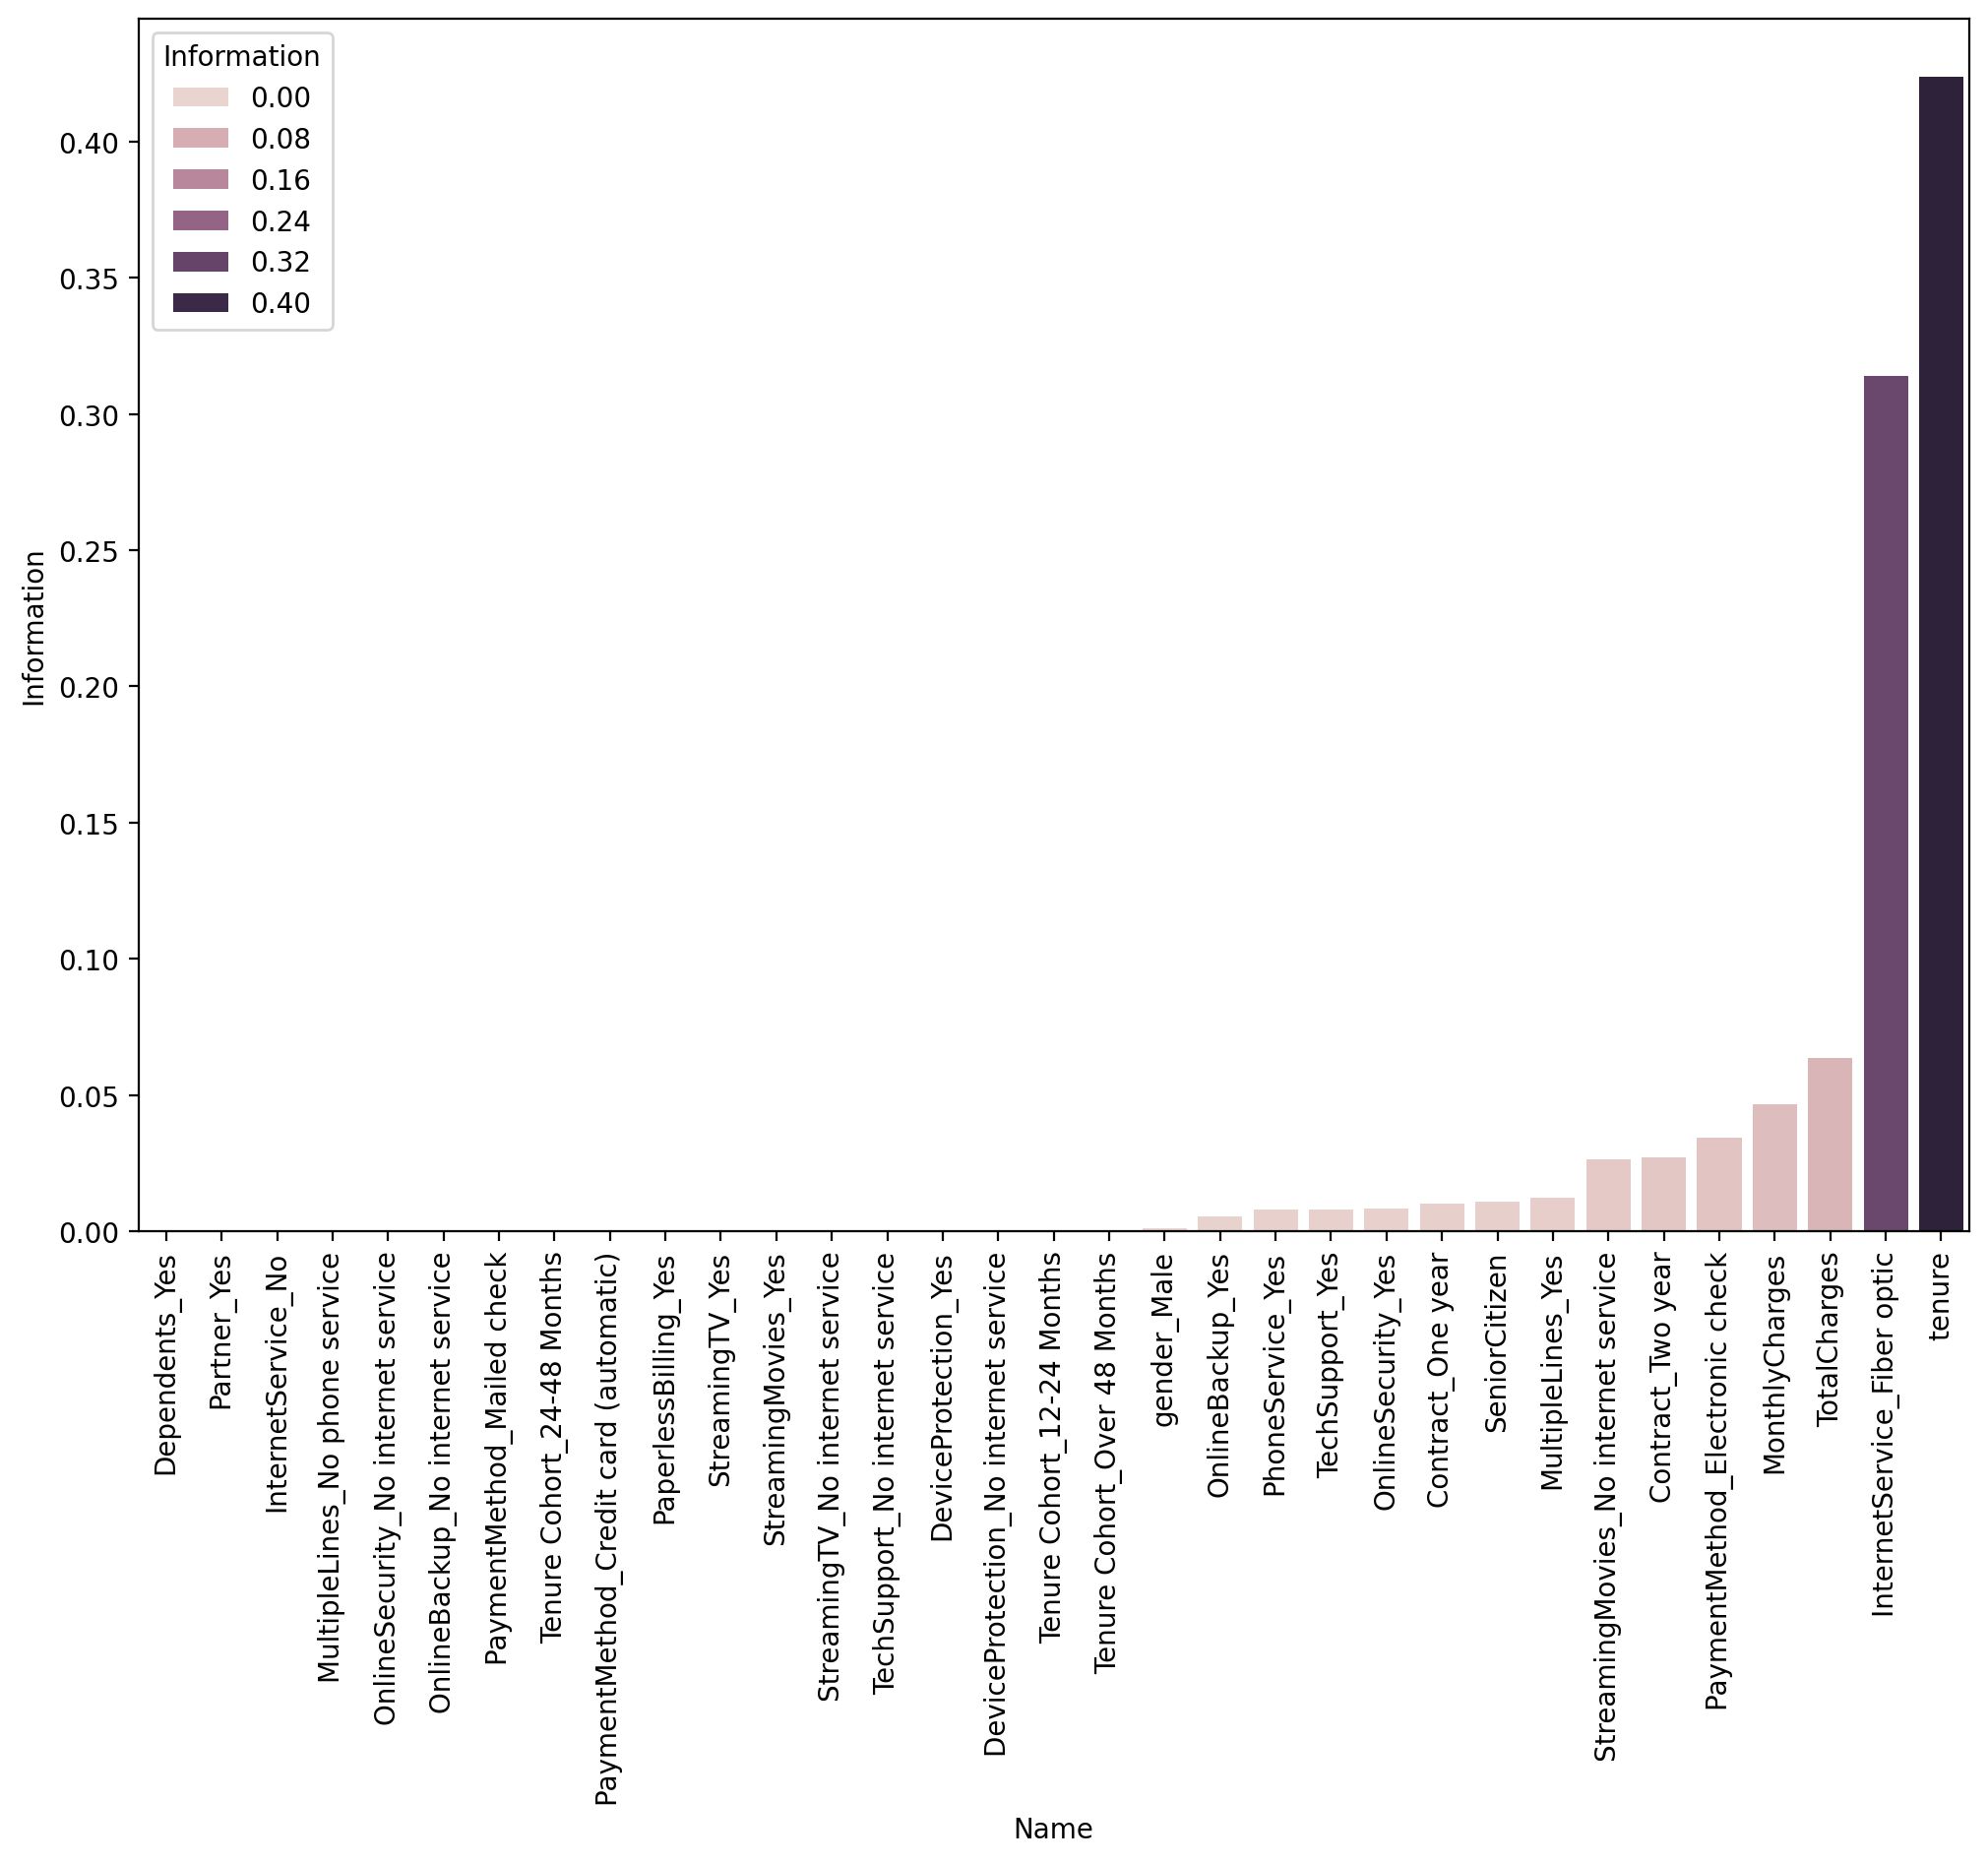

In [ ]:
plt.figure(figsize = (12,8) , dpi = 200)
sns.barplot(x = 'Name' , y = 'Information' , data = dx , hue = 'Information');
plt.xticks(rotation = 90);


In [ ]:
# With base models, we got best performance from an AdaBoostClassifier, but note, we didn't do any gridsearching AND most models performed about the same on the data set.
